In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 20


In [2]:
ra_center, dec_center =212.62429809570312, 0.678357720375061 #1
# ra_center, dec_center =185.6293182373047, 1.0146928663253784 #2
# ra_center, dec_center =222.2838592529297, 1.003072924232483 #3
user = 'hyp0515'
password = 'PHFrCTavyczTCw/onxRGH537qhiLWqYSRuHB6WHE'
filter = 'HSC-R'

In [3]:
rect = downloadCutout.Rect.create(
    ra=	ra_center,
    dec=dec_center,
    sw="20arcsec",
    sh="20arcsec",
    variance=True,
    mask=True,
    filter=filter,
)

images = downloadCutout.download(rect, user=user, password=password)
_, image_data = images[0]
image_hdu = astropy.io.fits.open(io.BytesIO(image_data))
image_hdu.info()
image = image_hdu[1].data
mask  = image_hdu[2].data
print(np.max(mask), np.min(mask))
print(mask[mask.shape[0]//2, mask.shape[1]//2])
var   = image_hdu[3].data

psfreq = downloadPsf.PsfRequest.create(
    ra=ra_center,
    dec=dec_center,
    filter=filter
)
psfs = downloadPsf.download(psfreq, user=user, password=password)
print(psfs)
_, psf_data = psfs[0]
psf_hdu = astropy.io.fits.open(io.BytesIO(psf_data))
psf_hdu.info()
psf = psf_hdu[0].data


Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   ()      
  1                1 ImageHDU        44   (239, 239)   float32   
  2                1 ImageHDU        60   (239, 239)   int32   
  3                1 ImageHDU        44   (239, 239)   float32   
106528 0
32
[({'lineno': 0, 'rerun': 'pdr3_wide', 'filter': 'HSC-R', 'tract': 9613, 'type': 'coadd', 'patch': (8, 4), 'psfreq': PsfRequest(rerun='pdr3_wide', type='coadd', filter='HSC-R', tract=9613, patch=(8, 4), ra=212.62429809570312, dec=0.678357720375061, centered=True, name='{lineno}_psf_{type}_{ra:.5f}_{dec:+.5f}_{tract}_{patch[0]},{patch[1]}_{filter}', lineno=0)}, b'SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -64 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                   43 / length of 

19065.110787067635


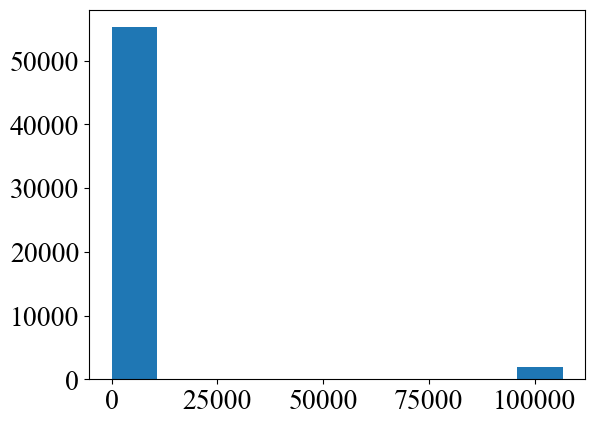

In [4]:
print(np.std(mask.flatten()))
plt.hist(mask.flatten())
plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_62291/924827761.py:2: RuntimeWarning: invalid value encountered in log10
  ax[0].imshow(np.where(image > 1, np.log10(image), 0), cmap="gray_r", origin="lower")


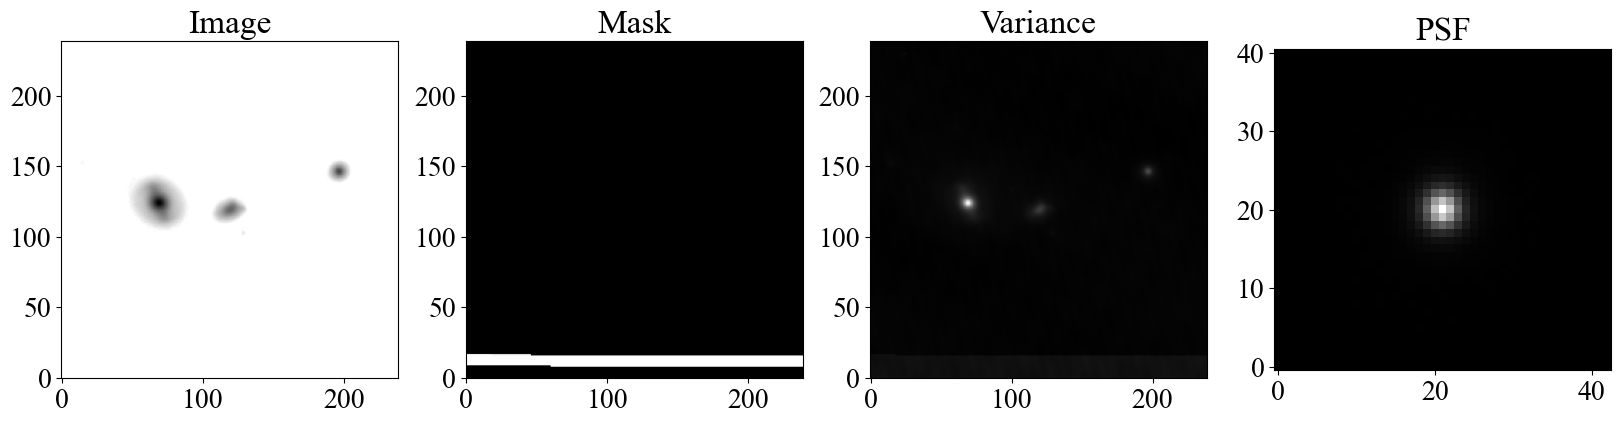

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(np.where(image > 1, np.log10(image), 0), cmap="gray_r", origin="lower")
# ax[0].contour(Z, contour_levels, colors=contour_colors, linewidths=1.5)
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.show()

In [6]:
threshold = detect_threshold(image, 3,)
npixels = 200  # minimum number of connected pixels
segmap = detect_sources(image, threshold, npixels)
segmap = np.array(segmap)
segmap = np.where(segmap != segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)], 0, 1)
print(segmap.shape)

(239, 239)


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_62291/1032769797.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  segmap = np.array(segmap)


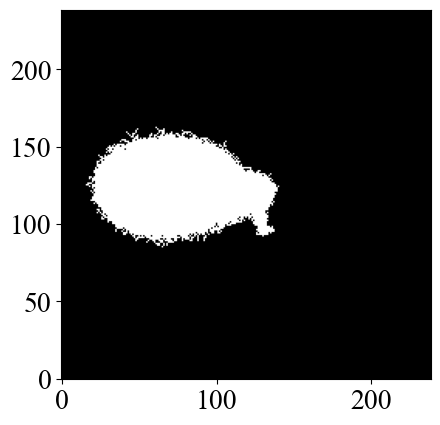

In [7]:
plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()

In [8]:
new_mask = np.zeros_like(mask)
new_mask[segmap == 1] = 0
new_mask[segmap == 0] = np.where((mask[segmap == 0]>=np.min(mask[segmap == 0])+np.std(mask.flatten()))|(image[segmap == 0]>=np.max(image[segmap == 1])*2/3), 1, 0)
mask = new_mask.astype(bool)
# mask = np.zeros_like(mask)  # --- IGNORE ---

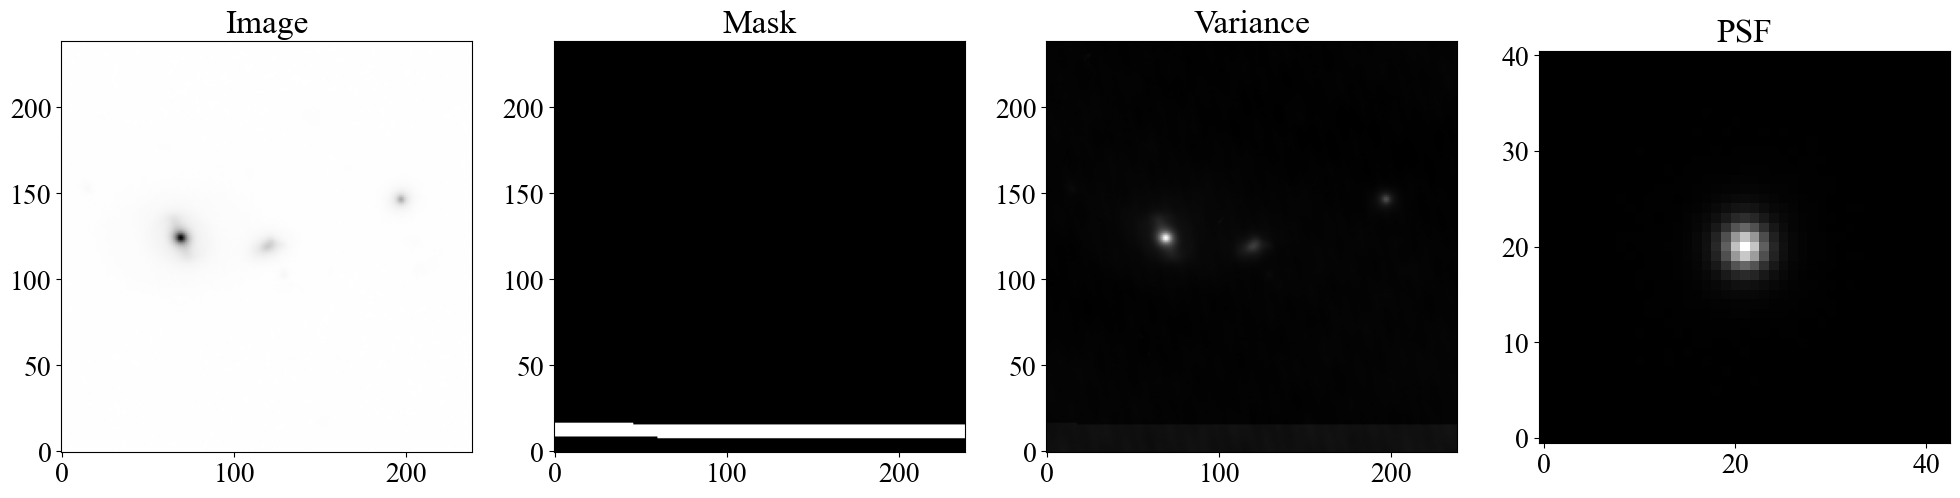

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.tight_layout()
plt.savefig('./figures/progress_apr/hsc_cutout.png')
plt.show()

In [10]:
start = time.time()
source_morphs = statmorph.source_morphology(image=image, segmap=segmap, psf=psf, weightmap=np.sqrt(var), mask=mask)
print('Time: %g s.' % (time.time() - start))

Time: 0.823894 s.


In [11]:
morph = source_morphs[0]

In [12]:
print('BASIC MEASUREMENTS (NON-PARAMETRIC)')
print('Gini =', morph.gini)
print('M20 =', morph.m20)
print('F(G, M20) =', morph.gini_m20_bulge)
print('S(G, M20) =', morph.gini_m20_merger)
print('C =', morph.concentration)
print('A =', morph.asymmetry)
print('S =', morph.smoothness)
print('A_s =', morph.shape_asymmetry)
print()
print('SERSIC MODEL')
print('sersic_amplitude =', morph.sersic_amplitude)
print('sersic_rhalf =', morph.sersic_rhalf)
print('sersic_n =', morph.sersic_n)
print('sersic_xc =', morph.sersic_xc)
print('sersic_yc =', morph.sersic_yc)
print('sersic_ellip =', morph.sersic_ellip)
print('sersic_theta =', morph.sersic_theta)
print('sersic_chi2_dof =', morph.sersic_chi2_dof)

BASIC MEASUREMENTS (NON-PARAMETRIC)
Gini = 0.6229269775928877
M20 = -1.5362468342992834
F(G, M20) = 0.1881075952541975
S(G, M20) = 0.07615939784935843
C = 4.1586467611418705
A = 0.2734966933537757
S = 0.002976835751797392
A_s = 0.23537492492445716

SERSIC MODEL
sersic_amplitude = 1.1780874710917866
sersic_rhalf = 22.36822519556613
sersic_n = 5.25801195455497
sersic_xc = 69.08484664840373
sersic_yc = 123.77274691073157
sersic_ellip = 0.2443540596562267
sersic_theta = 2.2708649677582446
sersic_chi2_dof = 46.50383162416285


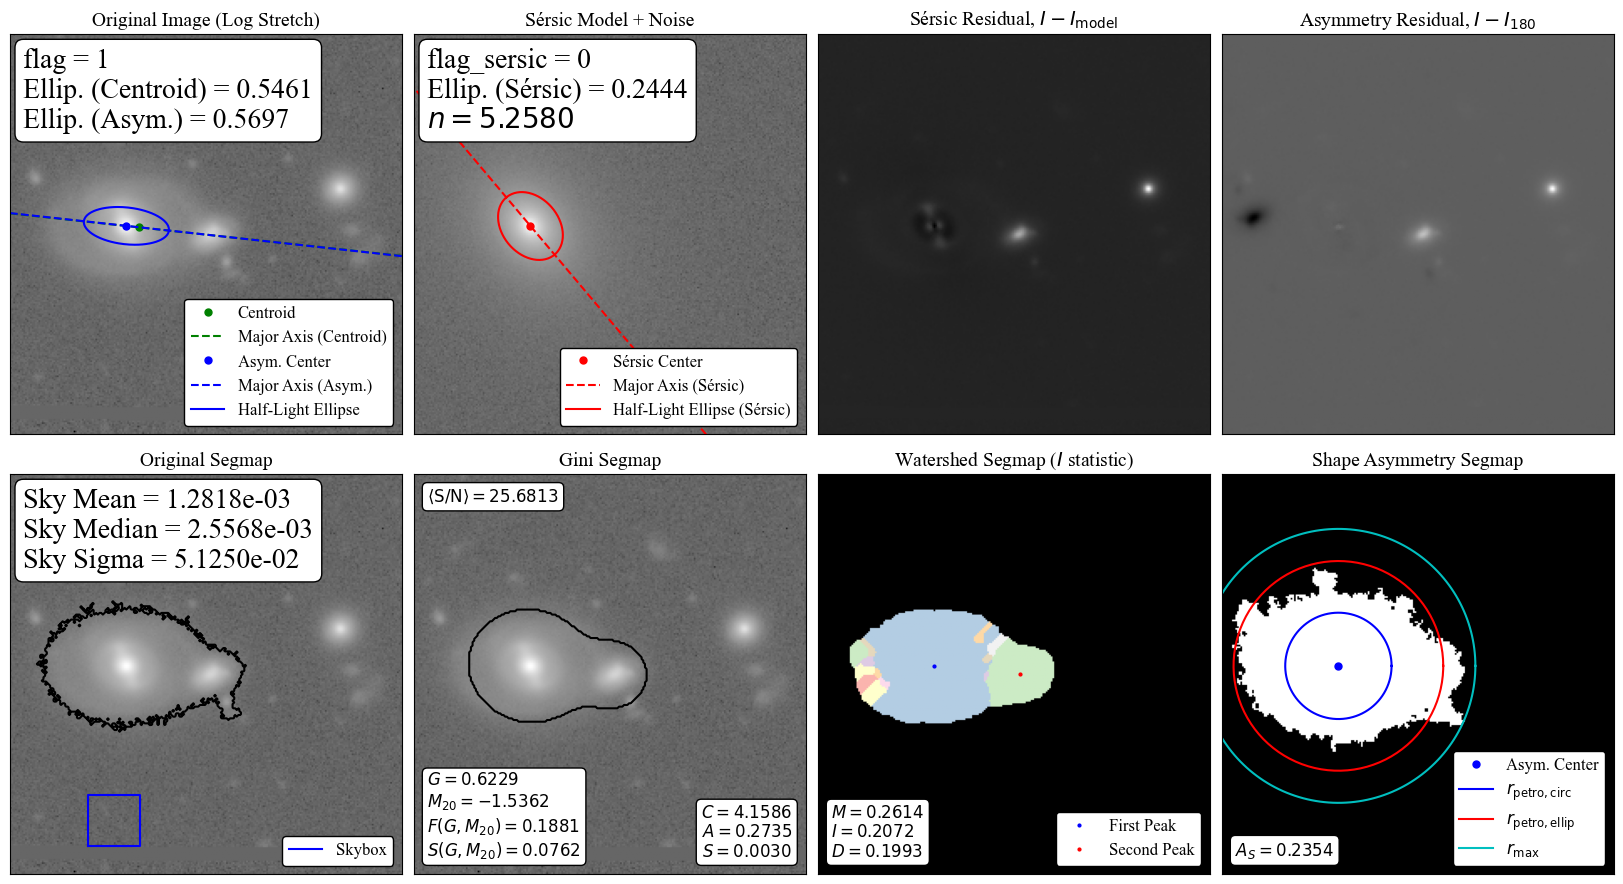

In [13]:
from statmorph.utils.image_diagnostics import make_figure
fig = make_figure(morph)
# fig.savefig('./figures/progress_apr/statmorph.png')

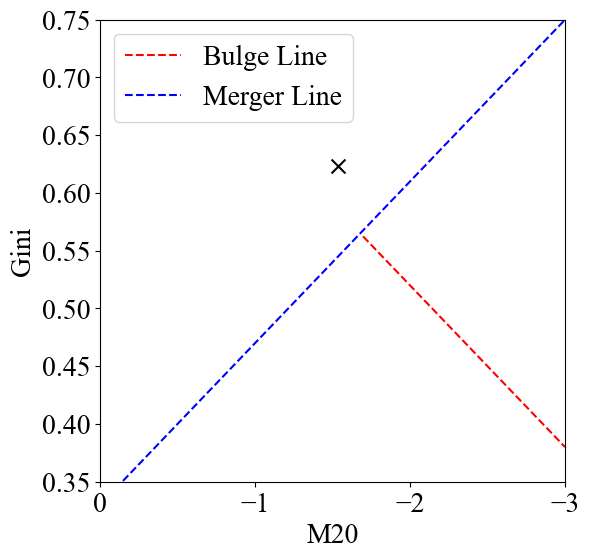

In [14]:
x = np.linspace(0, -3, 100)
merger_line = -0.14 * x + 0.33
bulge_line = 0.14 * x + 0.8
plt.figure(figsize=(6, 6))
plt.scatter(morph.m20, morph.gini, s=100, color='k', marker='x')
plt.plot(x[bulge_line<merger_line], bulge_line[bulge_line<merger_line], color='red', linestyle='--', label='Bulge Line')
plt.plot(x, merger_line, color='blue', linestyle='--', label='Merger Line')
plt.xlim((0, -3))
plt.ylim((0.35, 0.75))
plt.xlabel('M20')
plt.ylabel('Gini')
plt.legend()
plt.show()

In [15]:
print(-0.693*morph.m20 + 4.95*morph.gini -3.96)
print(0.139*morph.m20 + 0.990*morph.gini -0.327)

0.1881075952541975
0.07615939784935843


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_62291/3413857179.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.where(morph._cutout_stamp_maskzeroed > 1, np.log10(morph._cutout_stamp_maskzeroed), 0), cmap="hot", origin="lower")
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_62291/3413857179.py:2: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.where(morph._cutout_stamp_maskzeroed > 1, np.log10(morph._cutout_stamp_maskzeroed), 0), cmap="hot", origin="lower")


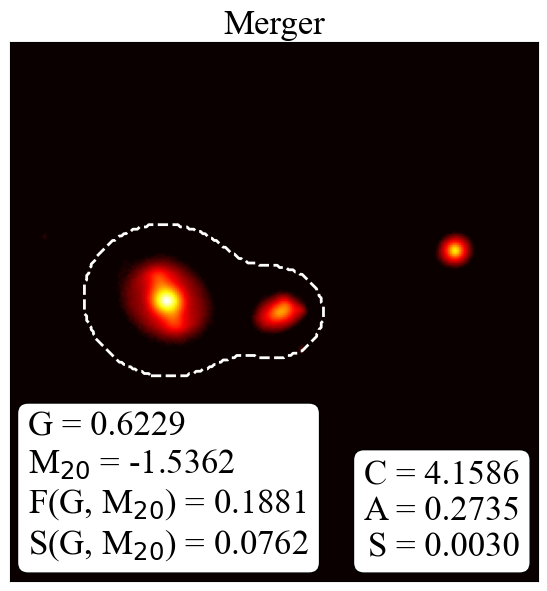

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.where(morph._cutout_stamp_maskzeroed > 1, np.log10(morph._cutout_stamp_maskzeroed), 0), cmap="hot", origin="lower")
contour_levels = [0.5]
contour_colors = [(0, 0, 0)]
Z = np.float64(morph._segmap_gini)
ax.contour(Z, contour_levels, colors='w', linewidths=2, linestyles='--')

text = (f'G = {morph.gini:.4f}' + '\n' +
        rf'M$_{{20}}$ = '+f'{morph.m20:.4f}' + '\n' +
        rf'F(G, M$_{{20}}$) = {morph.gini_m20_bulge:.4f}' + '\n' +
        rf'S(G, M$_{{20}}$) = {morph.gini_m20_merger:.4f}')
ax.text(0.034, 0.034, text, fontsize=25,
        horizontalalignment='left', verticalalignment='bottom',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=1.0, boxstyle='round'))
text = (f'C = {morph.concentration:.4f}' + '\n' +
        f'A = {morph.asymmetry:.4f}' + '\n' +
        f'S = {morph.smoothness:.4f}')
ax.text(0.966, 0.034, text, fontsize=25,
        horizontalalignment='right', verticalalignment='bottom',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=1.0, boxstyle='round'))

plt.title('Merger', fontsize=25)

plt.xticks([])
plt.yticks([])
# plt.savefig('./figures/asroc/statmorph_1.pdf', bbox_inches='tight', transparent=True)
plt.show()